# Target Pipeline EDA and Analysis with PySpark

Run the pipeline first so the files under `output/` exist, then run this notebook top to bottom. All EDA and analysis computations below use a PySpark DataFrame; pandas is only used to plot the already-aggregated Spark results.

In [62]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "output"
CLEANED_DATA_PATH = OUTPUT_DIR / "cleaned__target_data.csv"
CITY_REPORT_DIR = OUTPUT_DIR / "sales_by_city_report"

if not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError("Run the pipeline first so output/cleaned__target_data.csv exists.")

spark = (
    SparkSession.builder.appName("target-pipeline-eda")
    .master("local[*]")
    .config("spark.sql.warehouse.dir", str(OUTPUT_DIR / "spark-warehouse"))
    .enableHiveSupport()
    .getOrCreate()
)

spark_df = spark.read.option("header", True).option("inferSchema", True).csv(str(CLEANED_DATA_PATH))

spark_df = (
    spark_df
    .withColumn("Id", F.col("Id").cast("int"))
    .withColumn("order_products_value", F.col("order_products_value").cast("double"))
    .withColumn("order_freight_value", F.col("order_freight_value").cast("double"))
    .withColumn("order_items_qty", F.col("order_items_qty").cast("int"))
    .withColumn("customer_zip_code_prefix", F.col("customer_zip_code_prefix").cast("int"))
    .withColumn("review_score", F.col("review_score").cast("double"))
    .withColumn("total_order_value", F.col("total_order_value").cast("double"))
    .withColumn("approval_delay_hours", F.col("approval_delay_hours").cast("double"))
    .withColumn("delivery_time_days", F.col("delivery_time_days").cast("double"))
    .withColumn("freight_ratio", F.col("freight_ratio").cast("double"))
    .withColumn("order_purchase_timestamp", F.to_timestamp("order_purchase_timestamp"))
    .withColumn("order_aproved_at", F.to_timestamp("order_aproved_at"))
    .withColumn("order_delivered_customer_date", F.to_timestamp("order_delivered_customer_date"))
    .withColumn("order_date", F.to_date("order_purchase_timestamp"))
    .withColumn("order_year", F.year("order_purchase_timestamp"))
    .withColumn("order_week_start", F.date_trunc("week", F.col("order_purchase_timestamp")))
)

spark_df.createOrReplaceTempView("target_cleaned")
print(f"Loaded {spark_df.count()} cleaned rows")

26/03/19 14:29:14 WARN Utils: Your hostname, Adityas-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.1.2 instead (on interface en0)
26/03/19 14:29:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 14:29:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded 978 cleaned rows


## Dataset Shape and Schema Check

In [63]:
spark_df.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_products_value: double (nullable = true)
 |-- order_freight_value: double (nullable = true)
 |-- order_items_qty: integer (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_aproved_at: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- review_score: double (nullable = true)
 |-- total_order_value: double (nullable = true)
 |-- approval_delay_hours: double (nullable = true)
 |-- delivery_time_days: double (nullable = true)
 |-- freight_ratio: double (nullable = true)
 |-- order_date: date (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_week_start: timestamp (nullable = true)



In [64]:
schema_summary_df = spark.createDataFrame(
    [(field.name, field.dataType.simpleString(), spark_df.filter(F.col(field.name).isNotNull()).count()) for field in spark_df.schema.fields],
    ["column", "dtype", "non_null_count"],
)
schema_summary_df.toPandas()

,column,dtype,non_null_count
0,Id,int,978
1,order_status,string,978
2,order_products_value,double,978
3,order_freight_value,double,978
4,order_items_qty,int,978
5,order_purchase_timestamp,timestamp,978
6,order_aproved_at,timestamp,978
7,order_delivered_customer_date,timestamp,978
8,customer_city,string,978
9,customer_state,string,978


## EDA Checklist

In [65]:
eda_summary_df = spark.sql(
    """
    SELECT 'row_count' AS metric, CAST(COUNT(*) AS DOUBLE) AS value FROM target_cleaned
    UNION ALL
    SELECT 'mean_order_products_value', AVG(order_products_value) FROM target_cleaned
    UNION ALL
    SELECT 'mean_order_freight_value', AVG(order_freight_value) FROM target_cleaned
    UNION ALL
    SELECT 'unique_states', CAST(COUNT(DISTINCT customer_state) AS DOUBLE) FROM target_cleaned
    UNION ALL
    SELECT 'average_delivery_time_days', AVG(delivery_time_days) FROM target_cleaned
    UNION ALL
    SELECT 'average_approval_delay_hours', AVG(approval_delay_hours) FROM target_cleaned
    UNION ALL
    SELECT 'average_review_score', AVG(review_score) FROM target_cleaned
    """
)
eda_summary_df.toPandas()

,metric,value
0,row_count,978.00
1,mean_order_products_value,127.85
2,mean_order_freight_value,21.41
3,unique_states,26.00
4,average_delivery_time_days,12.33
5,average_approval_delay_hours,10.41
6,average_review_score,4.09


In [66]:
missing_values_exprs = [
    F.sum(F.when(F.col(column).isNull(), 1).otherwise(0)).alias(column)
    for column in spark_df.columns
]
missing_values_row = spark_df.select(missing_values_exprs).collect()[0].asDict()
missing_values_pd = pd.DataFrame(
    [(column, missing_values_row[column]) for column in spark_df.columns],
    columns=["column", "missing_values"],
).sort_values(["missing_values", "column"], ascending=[False, True])
missing_values_pd

,column,missing_values
0,Id,0
13,approval_delay_hours,0
8,customer_city,0
9,customer_state,0
10,customer_zip_code_prefix,0
14,delivery_time_days,0
15,freight_ratio,0
6,order_aproved_at,0
16,order_date,0
7,order_delivered_customer_date,0


In [67]:
states_df = spark_df.select("customer_state").distinct().orderBy("customer_state")
print(f"Unique states: {states_df.count()}")
states_df.toPandas().T

Unique states: 26


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
customer_state,AC,AL,AM,BA,CE,DF,ES,GO,MA,MG,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO


In [69]:
total_orders = spark_df.count()
status_distribution_df = (
    spark_df.groupBy("order_status")
    .agg(F.count("Id").alias("order_count"))
    .withColumn(
        "order_percent",
        F.round(F.col("order_count") / F.lit(total_orders) * 100, 2),
    )
    .orderBy(F.desc("order_count"))
)
status_distribution_pd = status_distribution_df.toPandas()
status_distribution_pd

,order_status,order_count,order_percent
0,delivered,961,98.26
1,shipped,12,1.23
2,canceled,3,0.31
3,invoiced,1,0.10
4,processing,1,0.10


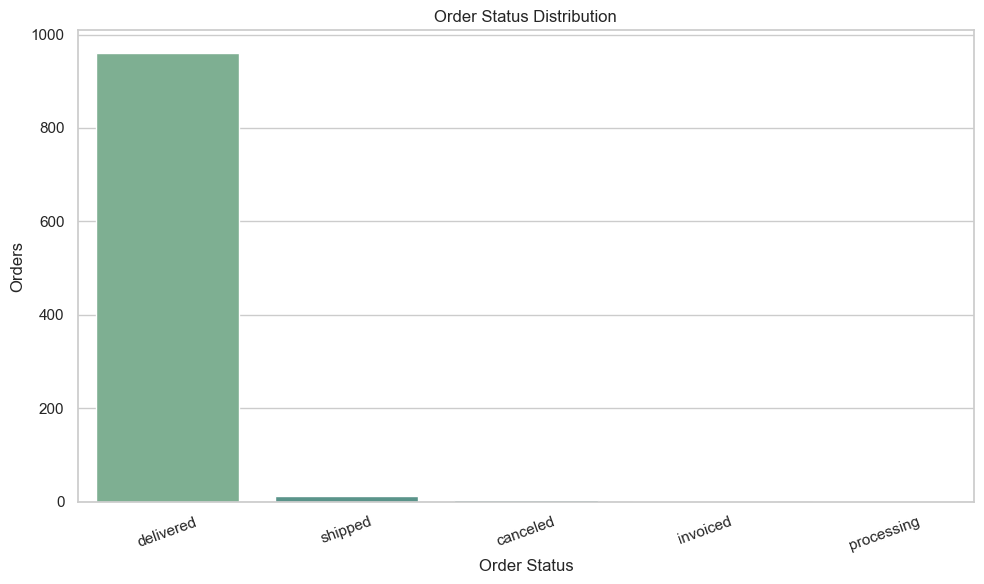

In [70]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=status_distribution_pd,
    x="order_status",
    y="order_count",
    hue="order_status",
    dodge=False,
    palette="crest",
    legend=False,
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

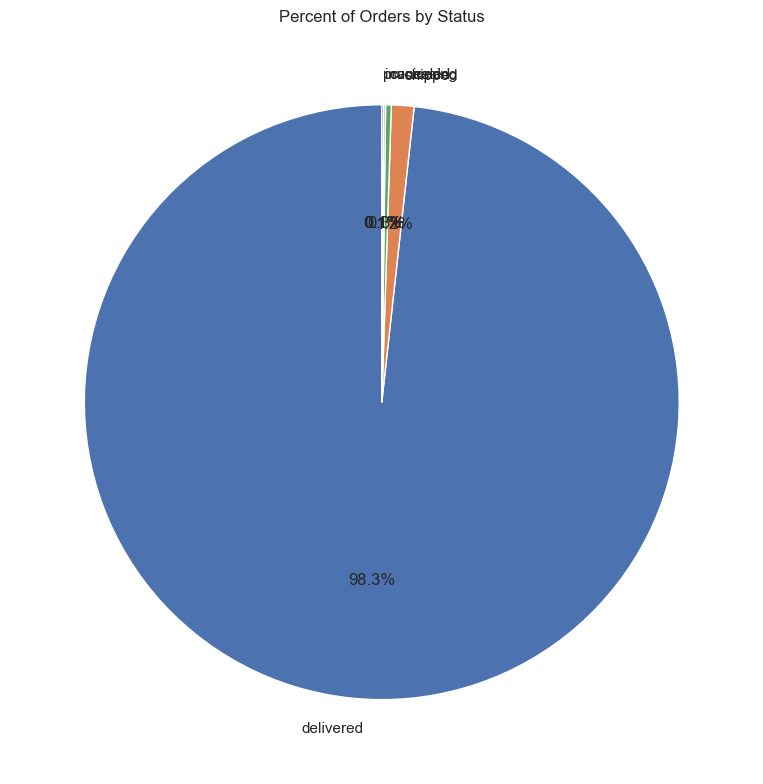

In [71]:
plt.figure(figsize=(8, 8))
plt.pie(
    status_distribution_pd["order_count"],
    labels=status_distribution_pd["order_status"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Percent of Orders by Status")
plt.tight_layout()
plt.show()

In [72]:
top_order_cities_df = (
    spark_df.groupBy("customer_city", "customer_state")
    .agg(F.count("Id").alias("order_count"))
    .orderBy(F.desc("order_count"), F.asc("customer_city"))
    .limit(5)
)
top_order_cities_pd = top_order_cities_df.toPandas()
top_order_cities_pd

,customer_city,customer_state,order_count
0,Sao Paulo,SP,147
1,Rio De Janeiro,RJ,71
2,Brasilia,DF,24
3,Belo Horizonte,MG,21
4,Curitiba,PR,19


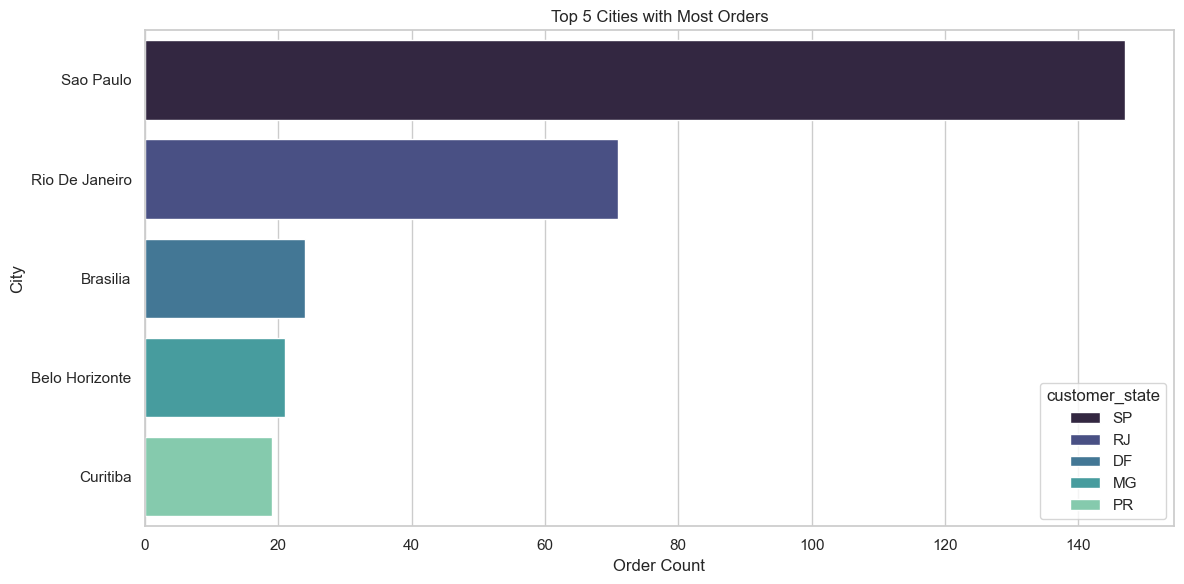

In [73]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_order_cities_pd,
    x="order_count",
    y="customer_city",
    hue="customer_state",
    dodge=False,
    palette="mako",
)
plt.title("Top 5 Cities with Most Orders")
plt.xlabel("Order Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## Analysis Checklist

In [74]:
sales_by_city_df = (
    spark_df.groupBy("customer_city", "customer_state")
    .agg(F.round(F.sum("total_order_value"), 2).alias("total_sales"))
    .orderBy(F.desc("total_sales"))
)
sales_by_city_pd = sales_by_city_df.limit(15).toPandas()
sales_by_city_df.limit(10).toPandas()

,customer_city,customer_state,total_sales
0,Sao Paulo,SP,"18,825.81"
1,Rio De Janeiro,RJ,"12,868.05"
2,Belo Horizonte,MG,"4,084.15"
3,Brasilia,DF,"2,652.86"
4,Curitiba,PR,"2,607.10"
5,Diadema,SP,"1,855.75"
6,Sao Goncalo,RJ,"1,621.56"
7,Fortaleza,CE,"1,601.98"
8,Limeira,SP,"1,573.05"
9,Santo Andre,SP,"1,531.92"


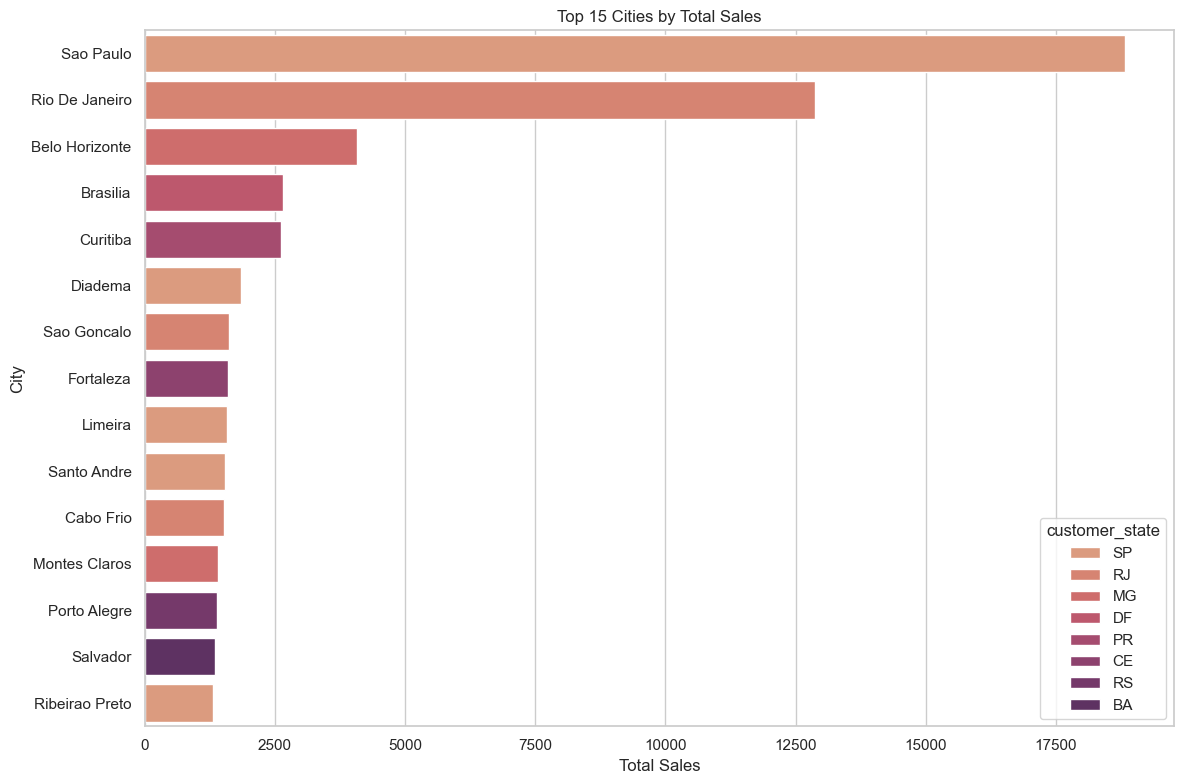

In [75]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=sales_by_city_pd,
    x="total_sales",
    y="customer_city",
    hue="customer_state",
    dodge=False,
    palette="flare",
)
plt.title("Top 15 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [76]:
correlation_pairs = [
    ("order_products_value", "order_freight_value"),
    ("order_products_value", "order_items_qty"),
    ("order_freight_value", "order_items_qty"),
    ("delivery_time_days", "review_score"),
]
correlation_results = []
for left, right in correlation_pairs:
    correlation_results.append((left, right, spark_df.stat.corr(left, right)))

correlation_pd = pd.DataFrame(correlation_results, columns=["left_column", "right_column", "correlation"])
correlation_pd["correlation"] = correlation_pd["correlation"].round(4)
correlation_pd

,left_column,right_column,correlation
0,order_products_value,order_freight_value,0.47
1,order_products_value,order_items_qty,0.26
2,order_freight_value,order_items_qty,0.63
3,delivery_time_days,review_score,0.02


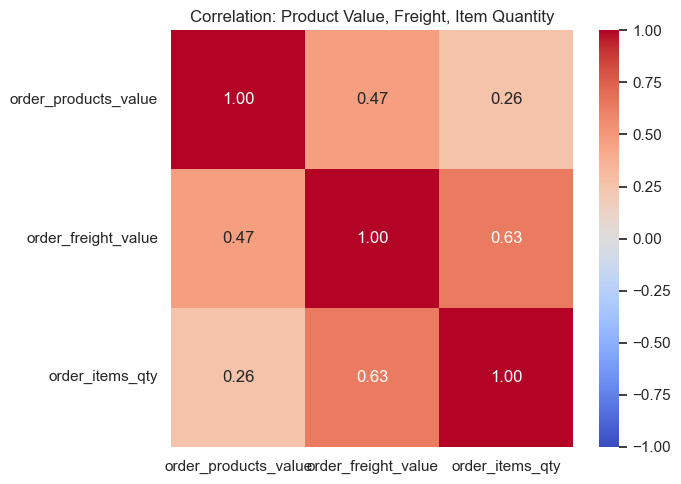

In [77]:
correlation_matrix_pd = pd.DataFrame(
    {
        "order_products_value": [1.0, spark_df.stat.corr("order_products_value", "order_freight_value"), spark_df.stat.corr("order_products_value", "order_items_qty")],
        "order_freight_value": [spark_df.stat.corr("order_products_value", "order_freight_value"), 1.0, spark_df.stat.corr("order_freight_value", "order_items_qty")],
        "order_items_qty": [spark_df.stat.corr("order_products_value", "order_items_qty"), spark_df.stat.corr("order_freight_value", "order_items_qty"), 1.0],
    },
    index=["order_products_value", "order_freight_value", "order_items_qty"],
).round(4)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix_pd, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation: Product Value, Freight, Item Quantity")
plt.tight_layout()
plt.show()

In [78]:
timing_summary_df = spark_df.agg(
    F.round(F.avg("delivery_time_days"), 2).alias("average_delivery_time_days"),
    F.round(F.avg("approval_delay_hours"), 2).alias("average_approval_delay_hours"),
)
timing_summary_df.toPandas()

,average_delivery_time_days,average_approval_delay_hours
0,12.33,10.41


In [79]:
average_review_per_order_df = (
    spark_df.groupBy("Id")
    .agg(F.round(F.avg("review_score"), 2).alias("average_review_score"))
    .orderBy(F.desc("average_review_score"), F.asc("Id"))
)
average_review_per_order_df.limit(10).toPandas()

,Id,average_review_score
0,1,5.00
1,2,5.00
2,5,5.00
3,6,5.00
4,7,5.00
5,9,5.00
6,10,5.00
7,15,5.00
8,18,5.00
9,21,5.00


In [80]:
average_review_score_value = average_review_per_order_df.agg(F.round(F.avg("average_review_score"), 2).alias("value")).collect()[0]["value"]
print(f"Average review score per order: {average_review_score_value}")

Average review score per order: 4.09


In [81]:
delivery_by_city_df = (
    spark_df.groupBy("customer_city", "customer_state")
    .agg(
        F.round(F.avg("delivery_time_days"), 2).alias("average_delivery_time_days"),
        F.count("Id").alias("order_count"),
    )
    .filter(F.col("order_count") >= 3)
)
fastest_cities_pd = delivery_by_city_df.orderBy(F.asc("average_delivery_time_days"), F.desc("order_count")).limit(3).toPandas()
slowest_cities_pd = delivery_by_city_df.orderBy(F.desc("average_delivery_time_days"), F.desc("order_count")).limit(3).toPandas()
print("Top 3 fastest delivery cities")
display(fastest_cities_pd)
print("Top 3 slowest delivery cities")
display(slowest_cities_pd)

Top 3 fastest delivery cities


,customer_city,customer_state,average_delivery_time_days,order_count
0,Cabo Frio,RJ,5.40,3
1,Pelotas,RS,6.30,3
2,Ipatinga,MG,6.92,3


Top 3 slowest delivery cities


,customer_city,customer_state,average_delivery_time_days,order_count
0,Contagem,MG,24.64,3
1,Orlandia,SP,22.33,3
2,Teresina,PI,20.08,3


In [83]:
review_delivery_df = (
    spark_df.groupBy("review_score")
    .agg(
        F.round(F.avg("delivery_time_days"), 2).alias("average_delivery_time_days"),
        F.count("Id").alias("order_count"),
    )
    .orderBy("review_score")
)
review_delivery_pd = review_delivery_df.toPandas()
review_delivery_pd

,review_score,average_delivery_time_days,order_count
0,1.00,11.92,115
1,2.00,11.03,25
2,3.00,12.82,80
3,4.00,12.06,193
4,5.00,12.49,565


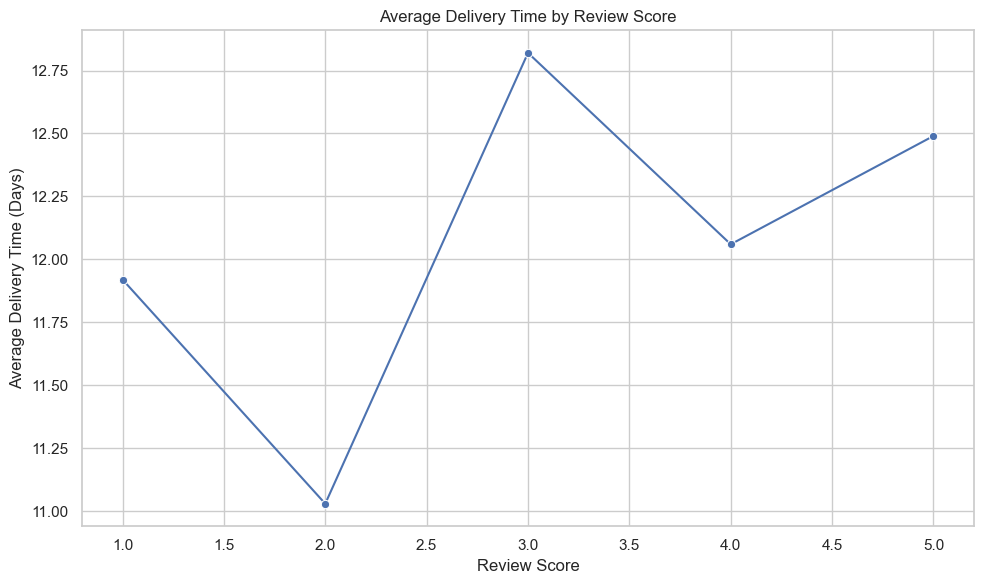

In [84]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=review_delivery_pd, x="review_score", y="average_delivery_time_days", marker="o")
plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")
plt.tight_layout()
plt.show()

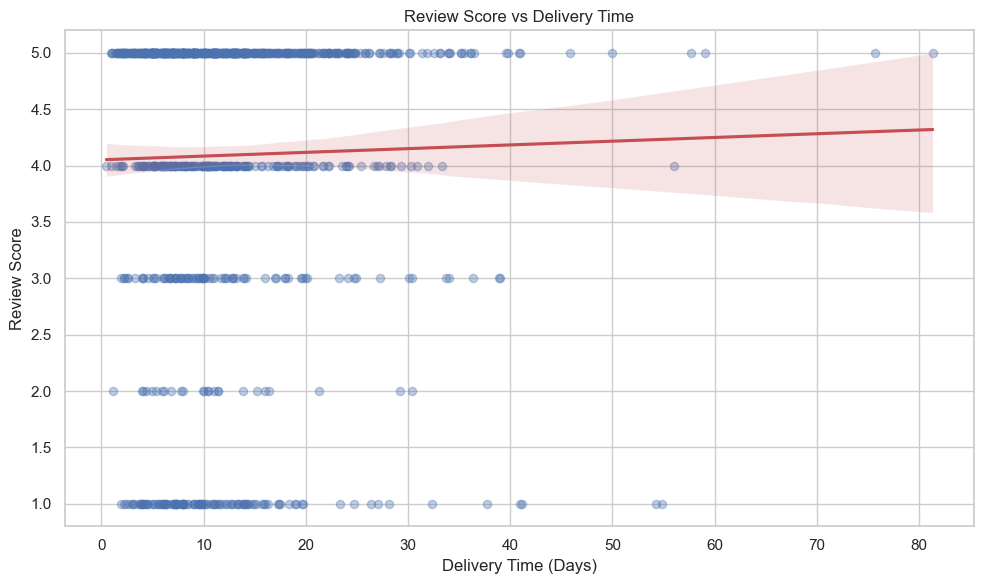

In [85]:
review_scatter_pd = spark_df.select("delivery_time_days", "review_score").toPandas()
plt.figure(figsize=(10, 6))
sns.regplot(
    data=review_scatter_pd,
    x="delivery_time_days",
    y="review_score",
    scatter_kws={"alpha": 0.35, "s": 35},
    line_kws={"color": "#c44e52"},
)
plt.title("Review Score vs Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

## Daily and Weekly Sales Views

In [86]:
daily_sales_df = (
    spark_df.groupBy("order_date")
    .agg(F.round(F.sum("total_order_value"), 2).alias("total_sales"))
    .orderBy("order_date")
)
daily_sales_pd = daily_sales_df.toPandas()
daily_sales_pd.head(10)

,order_date,total_sales
0,2016-10-05,318.33
1,2017-01-05,162.78
2,2017-01-14,44.57
3,2017-01-21,83.28
4,2017-01-22,159.37
5,2017-01-23,111.13
6,2017-01-25,31.78
7,2017-01-26,101.93
8,2017-01-27,262.94
9,2017-01-28,53.37


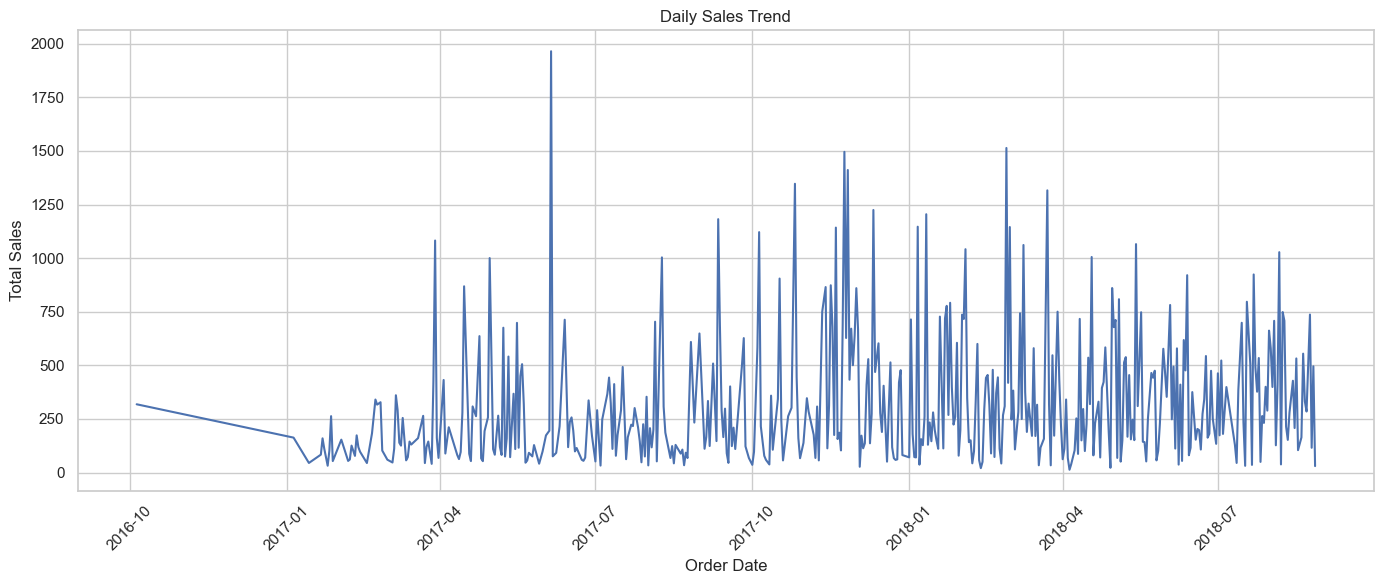

In [87]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales_pd, x="order_date", y="total_sales")
plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
weekly_sales_df = (
    spark_df.groupBy("order_week_start")
    .agg(F.round(F.sum("total_order_value"), 2).alias("total_sales"))
    .orderBy("order_week_start")
)
weekly_sales_pd = weekly_sales_df.toPandas()
weekly_sales_pd.head(10)

,order_week_start,total_sales
0,2016-10-03,318.33
1,2017-01-02,162.78
2,2017-01-09,44.57
3,2017-01-16,242.65
4,2017-01-23,561.15
5,2017-01-30,153.26
6,2017-02-06,609.87
7,2017-02-13,141.18
8,2017-02-20,"1,270.35"
9,2017-02-27,217.66


In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_sales_pd, x="order_week_start", y="total_sales", marker="o")
plt.title("Weekly Sales Trend")
plt.xlabel("Week Start")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Product Orders by Year

In [89]:
products_per_year_df = (
    spark_df.groupBy("order_year")
    .agg(F.sum("order_items_qty").alias("order_items_qty"))
    .orderBy("order_year")
)
products_per_year_pd = products_per_year_df.toPandas()
products_per_year_pd

,order_year,order_items_qty
0,2016,2
1,2017,498
2,2018,567


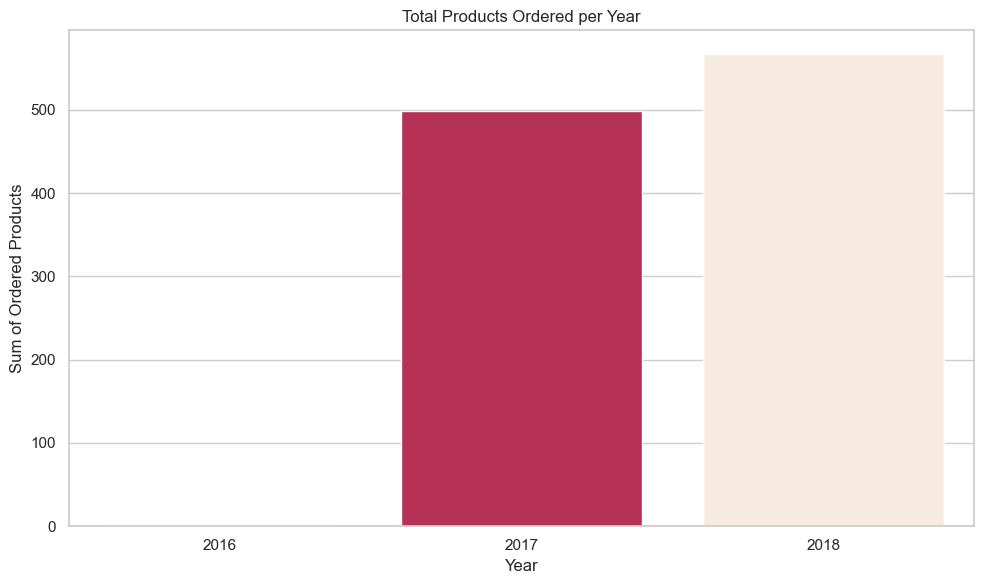

In [90]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=products_per_year_pd,
    x="order_year",
    y="order_items_qty",
    hue="order_year",
    dodge=False,
    palette="rocket",
    legend=False,
)
plt.title("Total Products Ordered per Year")
plt.xlabel("Year")
plt.ylabel("Sum of Ordered Products")
plt.tight_layout()
plt.show()

## Spark Output Check

,customer_city,customer_state,total_sales,avg_delivery_days,avg_review_score
0,Sao Paulo,SP,"18,825.81",13.00,4.24
1,Rio De Janeiro,RJ,"12,868.05",12.59,4.13
2,Belo Horizonte,MG,"4,084.15",12.57,3.95
3,Brasilia,DF,"2,652.86",10.72,3.79
4,Curitiba,PR,"2,607.10",13.74,3.95
5,Diadema,SP,"1,855.75",7.33,3.00
6,Sao Goncalo,RJ,"1,621.56",13.41,3.86
7,Fortaleza,CE,"1,601.98",10.73,4.22
8,Limeira,SP,"1,573.05",14.19,3.67
9,Santo Andre,SP,"1,531.92",11.99,4.64


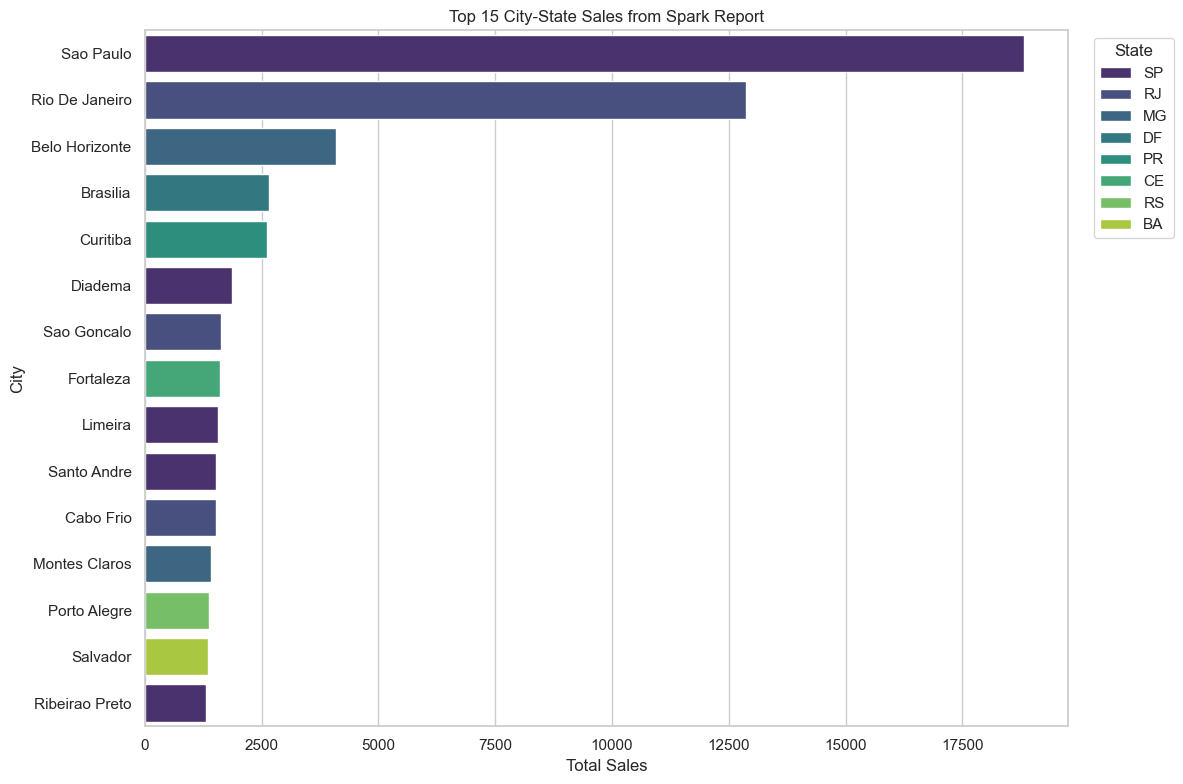

In [91]:
city_report_paths = sorted(CITY_REPORT_DIR.glob("part-*.csv"))
if city_report_paths:
    city_report_spark_df = spark.read.option("header", True).option("inferSchema", True).csv(str(city_report_paths[0]))
    city_report_pd = city_report_spark_df.orderBy(F.desc("total_sales")).limit(15).toPandas()
    display(city_report_spark_df.limit(10).toPandas())
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=city_report_pd,
        x="total_sales",
        y="customer_city",
        hue="customer_state",
        dodge=False,
        palette="viridis",
    )
    plt.title("Top 15 City-State Sales from Spark Report")
    plt.xlabel("Total Sales")
    plt.ylabel("City")
    plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No Spark city report found under output/sales_by_city_report/")